# Conditional Graph


In [79]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END 

In [80]:
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation1: str   # '+', '-', '*', or '/' for the first stage
    operation2: str   # '+', '-', '*', or '/' for the second stage
    result1: int
    result2: int

In [81]:
# ---- Stage 1 nodes ----
def add_node(state: AgentState) -> AgentState:
    """Adds number1 and number2."""
    state['result1'] = state['number1'] + state['number2']
    return state

def subtract_node(state: AgentState) -> AgentState:
    """Subtracts number2 from number1."""
    if state['number1'] < state['number2']:
        raise ValueError("number1 must be >= number2 for subtraction.")
    state['result1'] = state['number1'] - state['number2']
    return state

def multiply_node(state: AgentState) -> AgentState:
    """Multiplies number1 and number2."""
    state['result1'] = state['number1'] * state['number2']
    return state

def divide_node(state: AgentState) -> AgentState:
    """Divides number1 by number2."""
    if state['number2'] == 0:
        raise ValueError("number2 must not be zero for division.")
    state['result1'] = state['number1'] / state['number2']
    return state

# ---- Routing functions ----
def decide_next_node(state: AgentState) -> str:
    """Routes based on operation1."""
    if state['operation1'] == '+':
        return 'addition_operation'
    elif state['operation1'] == '-':
        return 'subtraction_operation'
    elif state['operation1'] == '*':
        return 'multiplication_operation'
    elif state['operation1'] == '/':
        return 'division_operation'
    else:
        raise ValueError("Invalid operation1 specified.")

In [82]:
# ---- Stage 2 nodes (operate on result from stage 1 + number3) ----
def add_node2(state: AgentState) -> AgentState:
    """Adds number3 and number4."""
    state['result2'] = state['number3'] + state['number4']
    return state

def subtract_node2(state: AgentState) -> AgentState:
    """Subtracts number4 from number3."""
    if state['number3'] < state['number4']:
        raise ValueError("number3 must be >= number4 for subtraction.")
    state['result2'] = state['number3'] - state['number4']
    return state

def multiply_node2(state: AgentState) -> AgentState:
    """Multiplies number3 and number4."""
    state['result2'] = state['number3'] * state['number4']
    return state

def divide_node2(state: AgentState) -> AgentState:
    """Divides number3 by number4."""
    if state['number4'] == 0:
        raise ValueError("number4 must not be zero for division.")
    state['result2'] = state['number3'] / state['number4']
    return state

# ---- Routing functions ----
def decide_next_node2(state: AgentState) -> str:
    """Routes based on operation2."""
    if state['operation2'] == '+':
        return 'addition_operation2'
    elif state['operation2'] == '-':
        return 'subtraction_operation2'
    elif state['operation2'] == '*':
        return 'multiplication_operation2'
    elif state['operation2'] == '/':
        return 'division_operation2'
    else:
        raise ValueError("Invalid operation2 specified.")

In [83]:
# ---- Build the graph ----
graph = StateGraph(AgentState)

graph.add_node('router', lambda state: state)   # pass-through
graph.add_node('add_node', add_node)
graph.add_node('subtract_node', subtract_node)
graph.add_node('multiply_node', multiply_node)
graph.add_node('divide_node', divide_node)

graph.add_node('router2', lambda state: state)  # pass-through
graph.add_node('add_node2', add_node2)
graph.add_node('subtract_node2', subtract_node2)
graph.add_node('multiply_node2', multiply_node2)
graph.add_node('divide_node2', divide_node2)

graph.add_edge(START, 'router')

graph.add_conditional_edges(
    'router',
    decide_next_node,
    {
        'addition_operation': 'add_node',
        'subtraction_operation': 'subtract_node',
        'multiplication_operation': 'multiply_node',
        'division_operation': 'divide_node',
    }
)

graph.add_edge('add_node', 'router2')
graph.add_edge('subtract_node', 'router2')
graph.add_edge('multiply_node', 'router2')
graph.add_edge('divide_node', 'router2')

graph.add_conditional_edges(
    'router2',
    decide_next_node2,
    {
        'addition_operation2': 'add_node2',
        'subtraction_operation2': 'subtract_node2',
        'multiplication_operation2': 'multiply_node2',
        'division_operation2': 'divide_node2',
    }
)

graph.add_edge('add_node2', END)
graph.add_edge('subtract_node2', END)
graph.add_edge('multiply_node2', END)
graph.add_edge('divide_node2', END)

app = graph.compile() # Compile the graph into an executable application

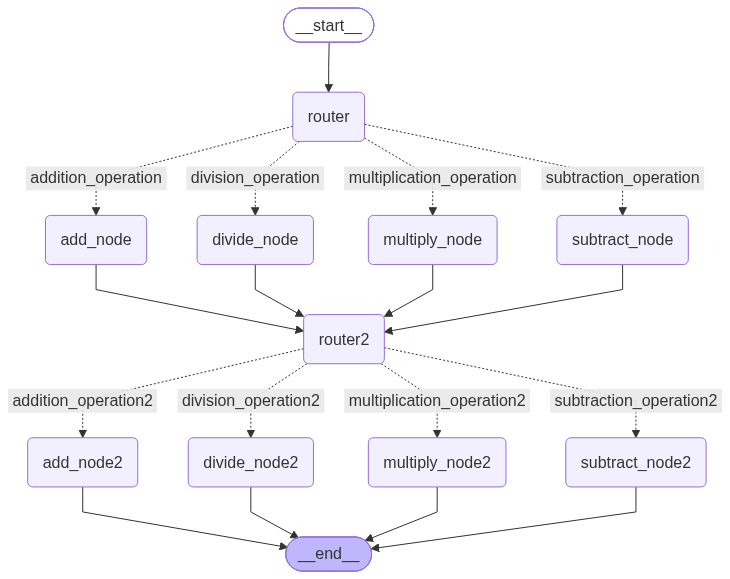

In [84]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))  # Display the graph image

In [85]:
result = app.invoke({
    'number1': 10,
    'number2': 4,
    'number3': 3,
    'number4': 2,
    'operation1': '*',
    'operation2': '+'
})
# result1 = 10 * 4 = 40
# result2 = 3 + 2 = 5

In [86]:
result

{'number1': 10,
 'number2': 4,
 'number3': 3,
 'number4': 2,
 'operation1': '*',
 'operation2': '+',
 'result1': 40,
 'result2': 5}

In [87]:
result['result1'], result['result2']

(40, 5)